In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('C:\\Users\\user\\Desktop\\ML Ops Project\\notebook\\TRAIN.csv')

In [3]:
df.head(2)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN23596,2,0,2,3,Meal Plan 1,0,Room_Type 1,188,2018,8,26,Online,0,0,0,90.95,0,Canceled
1,INN12127,1,0,1,4,Not Selected,0,Room_Type 1,20,2018,7,11,Online,0,0,0,139.00,0,Canceled


In [5]:
df.dtypes

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

<Axes: xlabel='market_segment_type'>

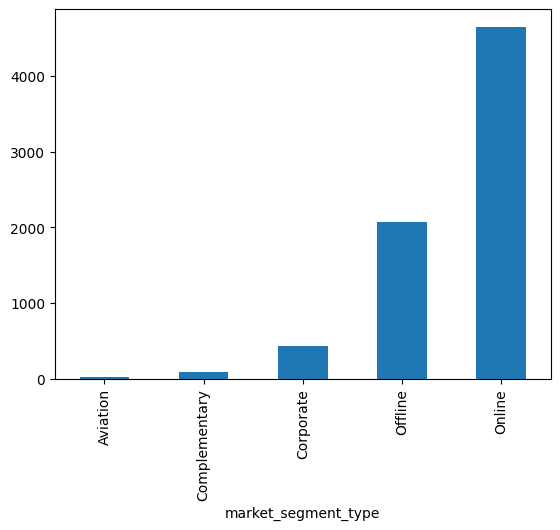

In [12]:
df.groupby('market_segment_type')['Booking_ID'].count().plot(kind='bar')

In [13]:
df_num=[x for x in df.columns if df[x].dtype!='O']

array([[<Axes: title={'center': 'no_of_adults'}>,
        <Axes: title={'center': 'no_of_children'}>,
        <Axes: title={'center': 'no_of_weekend_nights'}>,
        <Axes: title={'center': 'no_of_week_nights'}>],
       [<Axes: title={'center': 'required_car_parking_space'}>,
        <Axes: title={'center': 'lead_time'}>,
        <Axes: title={'center': 'arrival_year'}>,
        <Axes: title={'center': 'arrival_month'}>],
       [<Axes: title={'center': 'arrival_date'}>,
        <Axes: title={'center': 'repeated_guest'}>,
        <Axes: title={'center': 'no_of_previous_cancellations'}>,
        <Axes: title={'center': 'no_of_previous_bookings_not_canceled'}>],
       [<Axes: title={'center': 'avg_price_per_room'}>,
        <Axes: title={'center': 'no_of_special_requests'}>, <Axes: >,
        <Axes: >]], dtype=object)

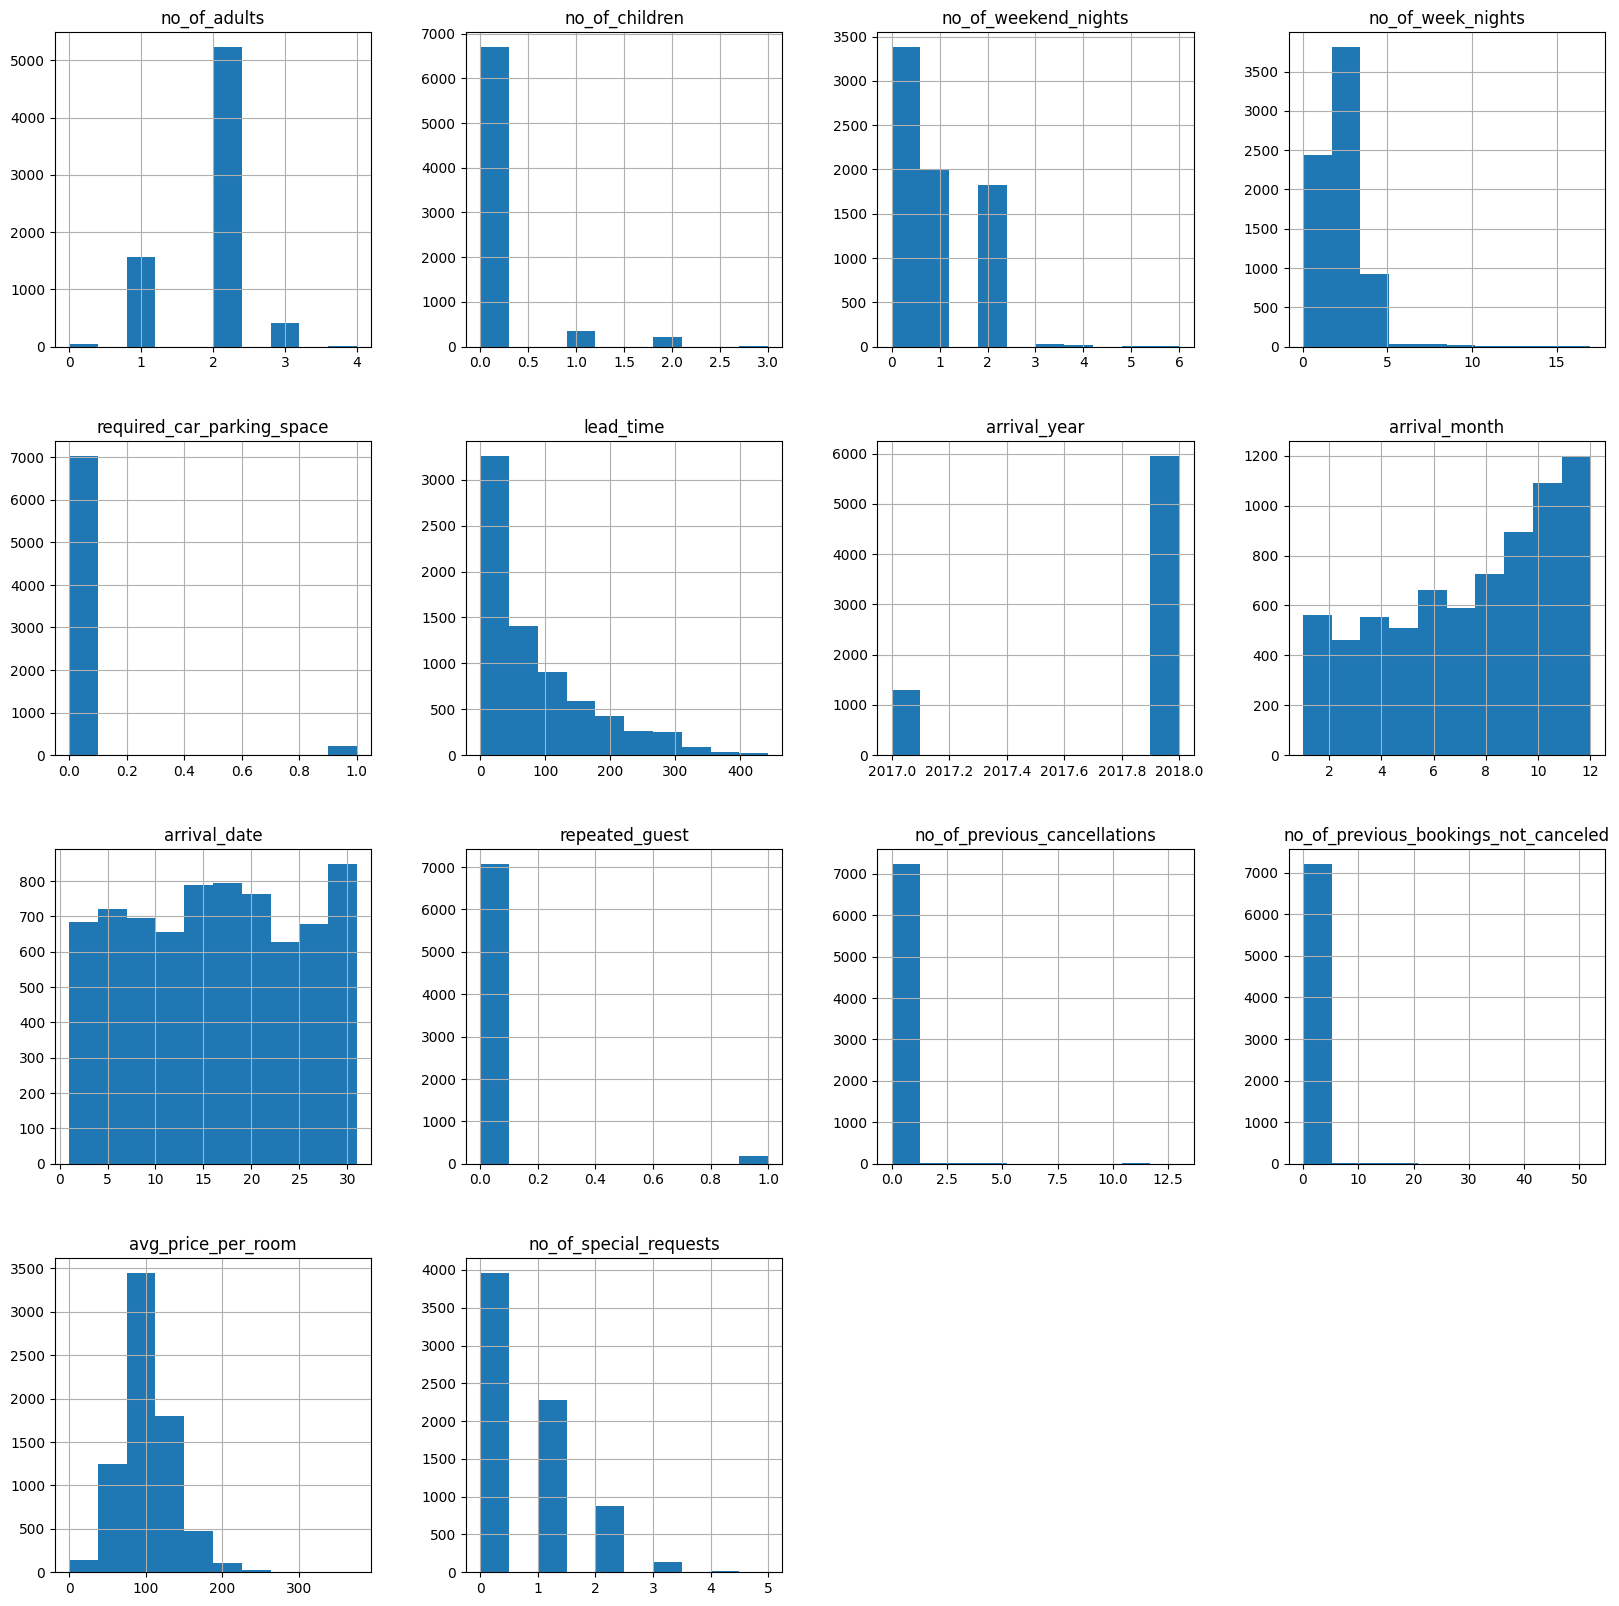

In [14]:
df[df_num].hist(figsize=(20,20))

In [15]:
df[df_num].corr()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
no_of_adults,1.000000,-0.035073,0.105502,0.097356,0.025325,0.087998,0.078656,0.004526,0.013695,-0.189086,-0.047503,-0.120918,0.291596,0.199235
no_of_children,-0.035073,1.000000,0.019536,0.037213,0.045507,-0.042219,0.050065,-0.005664,0.038241,-0.038025,-0.017304,-0.021565,0.350077,0.116452
no_of_weekend_nights,0.105502,0.019536,1.000000,0.146664,-0.031330,0.038448,0.052519,-0.010146,0.015760,-0.057184,-0.008152,-0.012792,-0.002199,0.057004
no_of_week_nights,0.097356,0.037213,0.146664,1.000000,-0.041201,0.153296,0.044009,0.014200,0.005747,-0.102473,-0.036580,-0.049914,0.029093,0.045492
required_car_parking_space,0.025325,0.045507,-0.031330,-0.041201,1.000000,-0.070375,0.017475,-0.027052,0.001872,0.081374,-0.002781,0.018735,0.083702,0.109777
lead_time,0.087998,-0.042219,0.038448,0.153296,-0.070375,1.000000,0.133400,0.119035,-0.007652,-0.135276,-0.044188,-0.077402,-0.065847,-0.113034
arrival_year,0.078656,0.050065,0.052519,0.044009,0.017475,0.133400,1.000000,-0.352260,0.028737,-0.006413,0.009797,0.026828,0.190469,0.060512
arrival_month,0.004526,-0.005664,-0.010146,0.014200,-0.027052,0.119035,-0.352260,1.000000,-0.057158,0.012060,-0.036650,-0.005361,0.060772,0.123833
arrival_date,0.013695,0.038241,0.015760,0.005747,0.001872,-0.007652,0.028737,-0.057158,1.000000,-0.017423,-0.011728,0.007308,0.022995,0.016235
repeated_guest,-0.189086,-0.038025,-0.057184,-0.102473,0.081374,-0.135276,-0.006413,0.012060,-0.017423,1.000000,0.388422,0.535744,-0.175379,0.000353


In [16]:
df['booking_status'].value_counts()

booking_status
Not_Canceled    4937
Canceled        2318
Name: count, dtype: int64

In [17]:
df_obj=[x for x in df.columns if df[x].dtype=='O']

In [19]:
df[df_obj].nunique()

Booking_ID             7255
type_of_meal_plan         4
room_type_reserved        6
market_segment_type       5
booking_status            2
dtype: int64

Now we will first create X and Y, X will have values which are features and Y will have the outputs

In [20]:
df['booking_status'].nunique()

2

In [21]:
Y=df['booking_status']

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
encoder=LabelEncoder()

In [25]:
Y_enc=encoder.fit_transform(Y)

In [26]:
from sklearn.preprocessing import OneHotEncoder

In [27]:
ohe=OneHotEncoder()

In [51]:
X_enc=ohe.fit_transform(df[df_obj].drop(['Booking_ID','booking_status'],axis=1))

In [75]:
X_enc=ohe.fit(df[df_obj].drop(['Booking_ID','booking_status'],axis=1))

In [52]:
df_X_enc=pd.DataFrame(X_enc.toarray(),columns=ohe.get_feature_names_out())

In [53]:
df_X_enc

,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7250,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7251,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7252,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7253,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [54]:
X_train=pd.concat([df_X_enc,df[df_num]],axis=1)

In [55]:
X_train.isnull().sum()

type_of_meal_plan_Meal Plan 1           0
type_of_meal_plan_Meal Plan 2           0
type_of_meal_plan_Meal Plan 3           0
type_of_meal_plan_Not Selected          0
room_type_reserved_Room_Type 1          0
room_type_reserved_Room_Type 2          0
room_type_reserved_Room_Type 4          0
room_type_reserved_Room_Type 5          0
room_type_reserved_Room_Type 6          0
room_type_reserved_Room_Type 7          0
market_segment_type_Aviation            0
market_segment_type_Complementary       0
market_segment_type_Corporate           0
market_segment_type_Offline             0
market_segment_type_Online              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
required_car_parking_space              0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                      

In [45]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Initialize the model for RFE
model = LogisticRegression()

# Initialize RFE with the model and desired number of features (e.g., 10)
rfe = RFE(model, n_features_to_select=10)

# Fit RFE on X_train and Y_enc
rfe.fit_transform(X_train, Y_enc)

# Get the selected features
selected_features = X_train.columns[rfe.support_]
print("Selected features:", selected_features)

c:\Users\user\Desktop\ML Ops Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\user\Desktop\ML Ops Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

Selected features: Index(['type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Not Selected', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online',
       'booking_status_Canceled', 'booking_status_Not_Canceled',
       'required_car_parking_space', 'no_of_special_requests'],
      dtype='object')


c:\Users\user\Desktop\ML Ops Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [57]:
from sklearn.feature_selection import VarianceThreshold

# Initialize VarianceThreshold (default threshold=0 removes features with zero variance)
vt = VarianceThreshold(.30)

# Fit and transform X_train
X_vt = vt.fit_transform(X_train)

# Get the selected feature names
selected_features_vt = X_train.columns[vt.get_support()]
print("Selected features using VarianceThreshold:", selected_features_vt)

Selected features using VarianceThreshold: Index(['no_of_weekend_nights', 'no_of_week_nights', 'lead_time',
       'arrival_month', 'arrival_date', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')


In [58]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Initialize RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Fit the model
rf.fit(X_train, Y_enc)

# Use SelectFromModel for feature selection
sfm = SelectFromModel(rf, prefit=True)
selected_features_rf = X_train.columns[sfm.get_support()]

print("Selected features using Random Forest:", selected_features_rf)

Selected features using Random Forest: Index(['no_of_weekend_nights', 'no_of_week_nights', 'lead_time',
       'arrival_month', 'arrival_date', 'avg_price_per_room',
       'no_of_special_requests'],
      dtype='object')


In [59]:
X_train = X_train[selected_features_rf]

In [61]:
import xgboost as xgb

In [62]:
classifer=xgb.XGBClassifier(random_state=42)

In [63]:
classifer.fit(X_train,Y_enc)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [64]:
Y_pred=classifer.predict(X_train)

In [65]:
from sklearn.metrics import classification_report, confusion_matrix

In [66]:
matrix=confusion_matrix(Y_enc,Y_pred)

In [67]:
confusion_matrix(Y_enc,Y_pred)

array([[2037,  281],
       [  95, 4842]])

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [69]:
accuracy_score,precision_score, recall_score, f1_score = accuracy_score(Y_enc, Y_pred), precision_score(Y_enc, Y_pred), recall_score(Y_enc, Y_pred), f1_score(Y_enc, Y_pred)

In [70]:
print(f"Accuracy: {accuracy_score}"
      f"\nPrecision: {precision_score}"
      f"\nRecall: {recall_score}"
      f"\nF1 Score: {f1_score}")

Accuracy: 0.9481736733287388
Precision: 0.945149326566465
Recall: 0.980757545067855
F1 Score: 0.962624254473161


In [72]:
import pickle as pkl

In [73]:
pkl.dump(classifer, open('xgb_model.pkl', 'wb'))


In [76]:
pkl.dump(ohe, open('encoder.pkl', 'wb'))

In [77]:
with open('selected_features.txt', 'w') as f:
    for feature in selected_features_rf:
        f.write(feature + '\n')

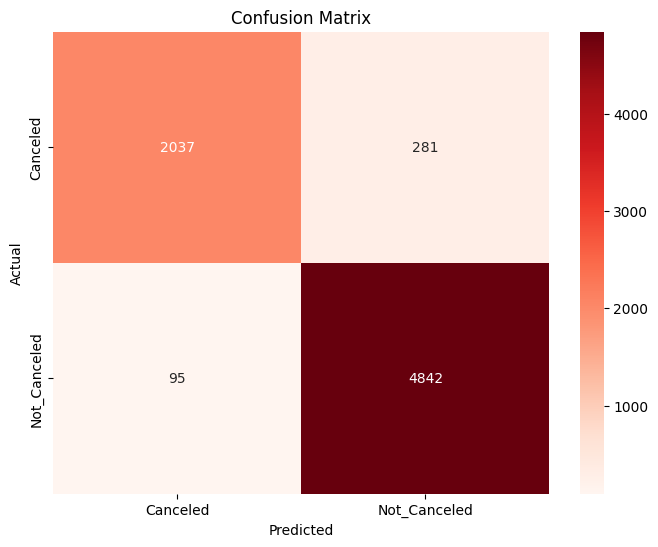

In [80]:
import seaborn as sns

import matplotlib.pyplot as plt

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Reds', xticklabels=['Canceled', 'Not_Canceled'], yticklabels=['Canceled', 'Not_Canceled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()